## 🏦 企業級信用風險評分與智慧決策系統 (Credit Risk Scoring & MLOps)
完整記錄資料探索、多表特徵工程、OOT 時間序列切分、模型訓練、商業成本矩陣最佳化及 SHAP 可分解釋性。

In [5]:


import pandas as pd
import numpy as np
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from src.preprocess import load_and_preprocess_data
from src.train import calculate_psi, optimize_cost_matrix

import warnings
warnings.filterwarnings('ignore')
print("環境初始化完成！")


環境初始化完成！


## 1. 探索性資料分析 (EDA)
檢查主檔大小與違約標籤（TARGET）的類別不平衡比例。

In [6]:
df_train_raw = pd.read_csv("data/application_train.csv")
print(f"主檔原始大小: {df_train_raw.shape}")

target_counts = df_train_raw['TARGET'].value_counts(normalize=True) * 100
print(f"正常客戶 (0): {target_counts[0]:.2f}%")
print(f"違約客戶 (1): {target_counts[1]:.2f}% (存在嚴重的類別不平衡)")

主檔原始大小: (307511, 122)
正常客戶 (0): 91.93%
違約客戶 (1): 8.07% (存在嚴重的類別不平衡)


## 2. 關聯式特徵工程 (Relational Feature Engineering)
呼叫 `preprocess.py` 模組，將 bureau、previous_application、installments_payments、POS_CASH、credit_card 進行聚合，萃取超過 500 維行為特徵。執行完整前處理與特徵工程

In [7]:
df = load_and_preprocess_data("data/application_train.csv")
print(f"特徵工程後完整數據集維度: {df.shape}")

正在載入主檔數據...
原始主檔大小: (307511, 122)
正在讀取並聚合 previous_application.csv...
previous_application 聚合完成！維度: (338857, 110)
正在讀取並聚合 installments_payments.csv (還款紀錄金礦)...
installments 聚合完成！維度: (339587, 17)
正在讀取並聚合 POS_CASH_balance.csv...
POS_CASH 聚合完成！維度: (337252, 33)
正在讀取並聚合 credit_card_balance.csv...
credit_card 聚合完成！維度: (103558, 43)
正在建立金融風控衍生特徵...
正在進行類別變數編碼...
正在處理數值型缺失值...
全表整併與預處理後總數據大小: (307511, 547)
特徵工程後完整數據集維度: (307511, 547)


## 3. OOT 時間序列切分 (Out-of-Time Validation)
依據申請流水號排序，模擬過去訓練、未來驗證的嚴格時序切分。

In [8]:
df = df.sort_values('SK_ID_CURR').reset_index(drop=True)
X = df.drop(columns=['SK_ID_CURR', 'TARGET'])
y = df['TARGET']

split_index = int(len(df) * 0.8)
X_train, X_val = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_val = y.iloc[:split_index], y.iloc[split_index:]

print(f"訓練集樣本數: {len(X_train)} | OOT 驗證集樣本數: {len(X_val)}")

訓練集樣本數: 246008 | OOT 驗證集樣本數: 61503


## 4. LightGBM 模型訓練與效能評估
引入 `scale_pos_weight` 處理類別不平衡，並透過早停法 (Early Stopping) 防止過擬合。

In [9]:
neg_count = np.sum(y_train == 0)
pos_count = np.sum(y_train == 1)
scale_pos_weight = neg_count / pos_count

train_data = lgb.Dataset(X_train, label=y_train)
val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'learning_rate': 0.03,
    'num_leaves': 31,
    'scale_pos_weight': scale_pos_weight,
    'random_state': 42,
    'verbose': -1
}

model = lgb.train(
    params, train_data, num_boost_round=1000,
    valid_sets=[train_data, val_data],
    callbacks=[lgb.early_stopping(50)]
)

val_preds = model.predict(X_val)
print(f"\nOOT 驗證集 ROC-AUC: {roc_auc_score(y_val, val_preds):.4f}")

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[576]	training's auc: 0.854931	valid_1's auc: 0.786404

OOT 驗證集 ROC-AUC: 0.7864


## 5. 商業決策與 MLOps 監控
- **成本矩陣**：尋找呆帳成本 (10x) 與機會成本 (1x) 的最佳平衡截斷點。
- **PSI 指標**：檢驗訓練集與驗證集分佈是否穩定。

In [10]:
best_th, lowest_cost = optimize_cost_matrix(y_val, val_preds)
print(f"💼 最佳放款門檻 (Threshold): {best_th:.4f} (最低總成本: {lowest_cost:.1f})")

train_preds = model.predict(X_train)
psi_score = calculate_psi(train_preds, val_preds)
print(f"📊 預測分佈 PSI 穩定度: {psi_score:.4f} (小於 0.1 代表無資料飄移)")


💼 最佳放款門檻 (Threshold): 0.5200 (最低總成本: 29739.0)
📊 預測分佈 PSI 穩定度: 0.0004 (小於 0.1 代表無資料飄移)


## 6. 模型可解釋性分析 (SHAP)
探索究竟是哪些關鍵特徵（如外部信用評分 EXT_SOURCE）在驅動模型的放款決策。

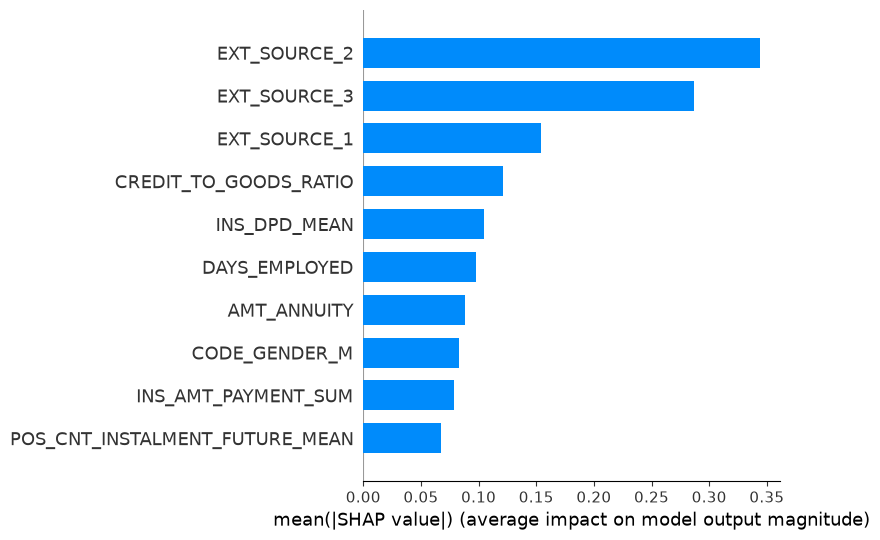

In [11]:
# 取部分驗證集樣本加速繪圖
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_val.iloc[:500])

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_val.iloc[:500], plot_type="bar", max_display=10)

圖表一：ROC 曲線 (驗證模型整體預測力)

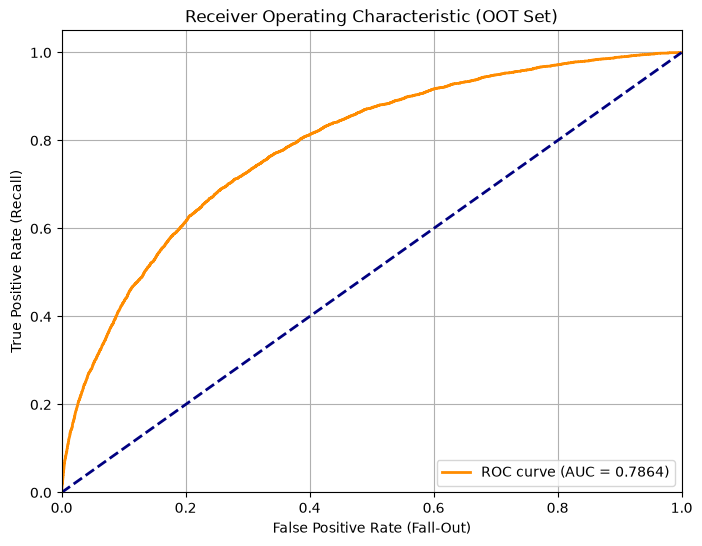

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 確保 X_val, y_val, val_preds 已經在內存中 (執行過 train.py)
fpr, tpr, thresholds = roc_curve(y_val, val_preds)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Fall-Out)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (OOT Set)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

圖表二：商業成本矩陣模擬圖 (尋找最佳門檻)

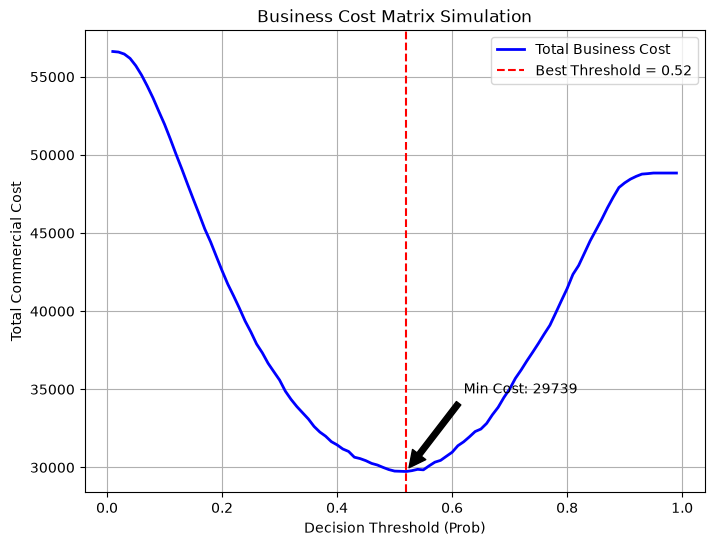

In [13]:
import numpy as np

# 重新執行一次成本模擬迴圈來收集數據以供繪圖
thresholds_, costs_ = [], []
test_ths = np.linspace(0.01, 0.99, 99)
cost_fn, cost_fp = 10.0, 1.0

for th in test_ths:
    y_pred_tmp = (val_preds >= th).astype(int)
    fn_tmp = np.sum((y_val == 1) & (y_pred_tmp == 0))
    fp_tmp = np.sum((y_val == 0) & (y_pred_tmp == 1))
    total_cost_tmp = (fn_tmp * cost_fn) + (fp_tmp * cost_fp)
    thresholds_.append(th)
    costs_.append(total_cost_tmp)

best_th_idx = np.argmin(costs_)
best_th_x = thresholds_[best_th_idx]
min_cost_y = costs_[best_th_idx]

plt.figure(figsize=(8, 6))
plt.plot(thresholds_, costs_, label='Total Business Cost', color='blue', lw=2)
plt.axvline(x=best_th_x, color='red', linestyle='--', label=f'Best Threshold = {best_th_x:.2f}')
plt.annotate(f'Min Cost: {min_cost_y:.0f}',
             xy=(best_th_x, min_cost_y), xytext=(best_th_x + 0.1, min_cost_y + 5000),
             arrowprops=dict(facecolor='black', shrink=0.05))
plt.xlabel('Decision Threshold (Prob)')
plt.ylabel('Total Commercial Cost')
plt.title('Business Cost Matrix Simulation')
plt.legend()
plt.grid(True)
plt.show()

圖表三：預測機率分佈直方圖 (視覺化 PSI)

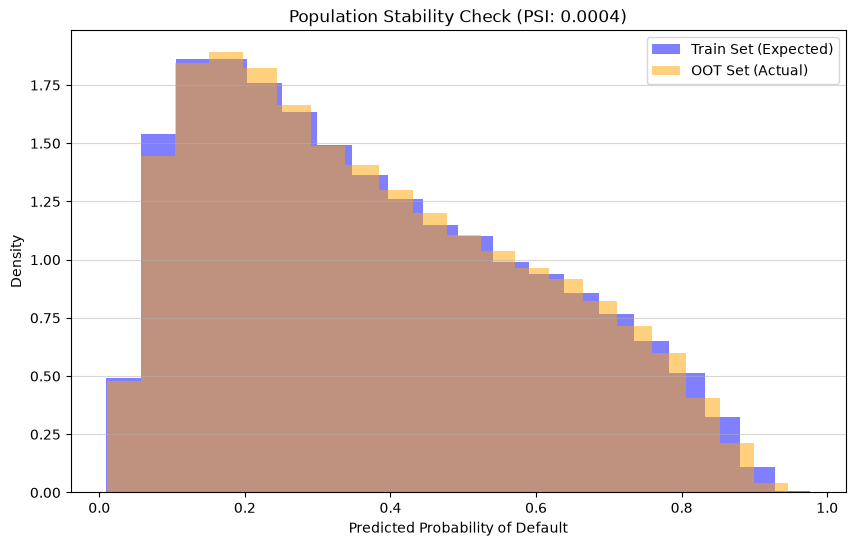

In [14]:
plt.figure(figsize=(10, 6))
plt.hist(train_preds, bins=20, alpha=0.5, label='Train Set (Expected)', density=True, color='blue')
plt.hist(val_preds, bins=20, alpha=0.5, label='OOT Set (Actual)', density=True, color='orange')
plt.xlabel('Predicted Probability of Default')
plt.ylabel('Density')
plt.title(f'Population Stability Check (PSI: {psi_score:.4f})')
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.5)
plt.show()

圖表四：SHAP 特徵重要性長條圖 (模型解釋力)

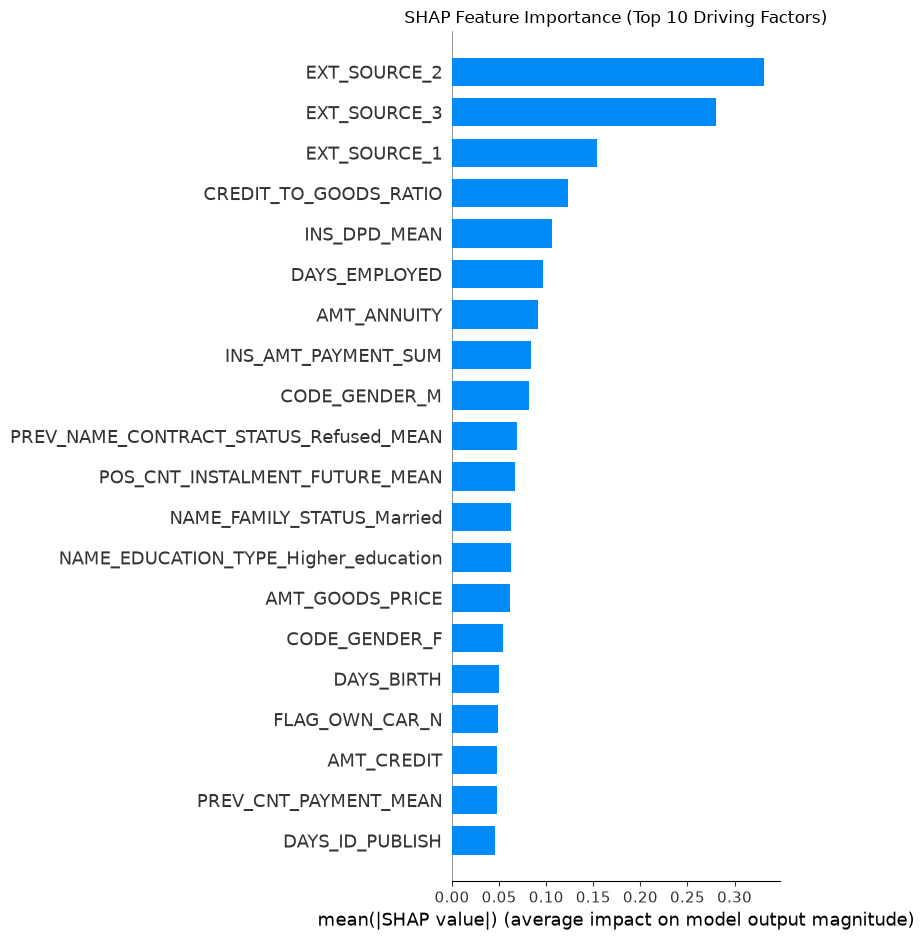

In [15]:
import shap

# 使用驗證集的前 1000 筆資料來計算 SHAP 值 (避免計算太久)
explainer = shap.TreeExplainer(model)
shap_values_sample = explainer.shap_values(X_val.iloc[:1000])

# 繪製 SHAP Summary Bar Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_sample, X_val.iloc[:1000], plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Top 10 Driving Factors)")
plt.tight_layout()
plt.show()